In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 01 — Rolling Window Setup

Partitions the processed Home Credit dataset into chronological time steps (one per **calendar month**) and enumerates the (Model A, Model B) window pairs for the rolling-retraining experiment.

**Input:** `data/processed/` (from notebook 00)
**Output:** `data/windows/window_config.json`

---

**Framework recap (§3.1):**
- Data partitioned into time steps D_{t1}, …, D_{tK} (one per calendar month).
- Training window: W_k = D_{t_{k-L+1}} ∪ … ∪ D_{t_k}  (fixed length L months).
- Model A trained on W_k, Model B on W_{k+S}.
- Common evaluation slice: E_{A,B} = D_{t_{k+S+1}} ∪ … ∪ D_{t_{k+S+H}}.
- **Pair stride** P controls how far apart consecutive pairs sit on the timeline (larger P → more temporal spread between pairs).

**Parameters used (Home Credit):**
| Parameter | Value | Meaning |
|-----------|-------|--------|
| L | 6 | training window length (months) |
| S | 2 | step between A and B inside one pair (months) |
| H | 2 | evaluation horizon (months) |
| P | 2 | pair stride — months between consecutive pairs |
| R | 8 | replicas per window |
| K_FRAC | 0.10 | top fraction of eval instances flagged |
| n_pairs_target | 5 | desired number of valid pairs |

The data spans roughly 22 months (2019-01 → 2020-10), so a single-pair k consumes (L + S + H) = 10 months. With P=2, pairs k=5, 7, 9, 11, 13 (0-based last-step-of-A) all fit comfortably.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/HomeCredit_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
WIN_DIR.mkdir(parents=True, exist_ok=True)

# ── Experiment parameters ────────────────────────────────────────────
L = 6             # training window length (time steps = months)
S = 2             # step between Model A and Model B windows (within a pair)
H = 2             # evaluation horizon (time steps)
P = 2             # pair stride — months between consecutive pairs
R = 3             # replicas per window
K_FRAC = 0.10     # top-K fraction of eval instances to flag
N_PAIRS_TARGET = 5  # desired number of valid pairs

print(f'Parameters: L={L}, S={S}, H={H}, P={P}, R={R}, K_FRAC={K_FRAC}, N_PAIRS_TARGET={N_PAIRS_TARGET}')

Parameters: L=6, S=2, H=2, P=2, R=3, K_FRAC=0.1, N_PAIRS_TARGET=5


## 1. Load processed data

In [3]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy')
meta = pd.read_parquet(PROC_DIR / 'meta.parquet')

# reset_index gives a clean 0-based integer index; storing it as 'row_idx'
# keeps a stable positional reference so rows can be located with .iloc on
# X and Y even after groupby / merge operations reshape the DataFrame.
meta = meta.reset_index(drop=True)
meta['row_idx'] = meta.index

# Make sure date_decision is a Timestamp.
meta['date_decision'] = pd.to_datetime(meta['date_decision'])

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'Date range: {meta["date_decision"].min()} → {meta["date_decision"].max()}')

X: (600000, 721), Y: (600000,)
Date range: 2019-01-01 00:00:00 → 2020-10-05 00:00:00


## 2. Define time steps (calendar months)

Loans per month:
month
2019-01-01    29862
2019-02-01    24929
2019-03-01    27086
2019-04-01    28217
2019-05-01    25425
2019-06-01    36943
2019-07-01    38426
2019-08-01    38689
2019-09-01    38827
2019-10-01    37431
2019-11-01    45256
2019-12-01    49697
2020-01-01    34101
2020-02-01    29770
2020-03-01    23825
2020-04-01     3245
2020-05-01    11255
2020-06-01    18211
2020-07-01    11268
2020-08-01    19975
2020-09-01    24114
2020-10-01     3448


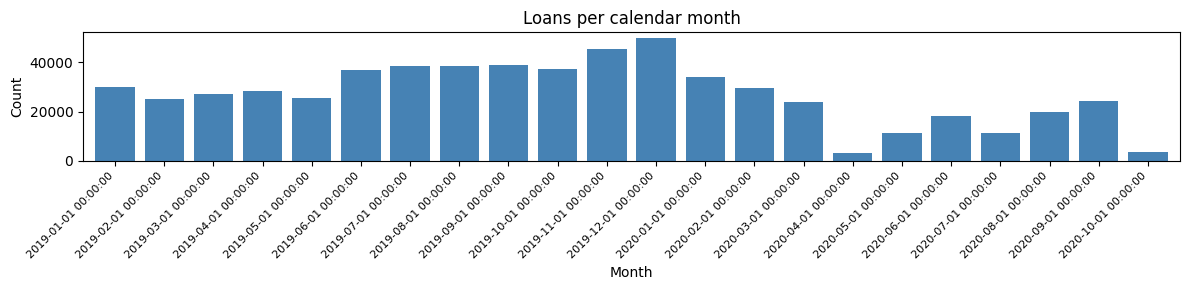

In [4]:
# Map every loan to the first day of its decision month — all loans in the same
# calendar month share an identical 'month' timestamp regardless of the exact day.
meta['month'] = meta['date_decision'].dt.to_period('M').dt.start_time

# Count loans per month to inspect how the data is distributed over time.
# Highly uneven counts can affect training stability.
month_counts = meta.groupby('month').size().sort_index()
print('Loans per month:')
print(month_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 3))
month_counts.plot(ax=ax, kind='bar', color='steelblue', width=0.8)
ax.set_title('Loans per calendar month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(WIN_DIR / 'loans_per_month.png', dpi=120)
plt.show()

In [5]:
# Sorting gives the canonical temporal ordering t_1 … t_K used throughout
# the experiment. All step indices below are 0-based (t_1 → 0, t_K → K-1).
time_steps = sorted(month_counts.index.tolist())
K = len(time_steps)
print(f'K = {K} time steps (months)')
for i, ts in enumerate(time_steps):
    n = month_counts[ts]
    print(f'  t_{i+1:2d}: {ts.strftime("%Y-%m")}  ({n:,} loans)')

K = 22 time steps (months)
  t_ 1: 2019-01  (29,862 loans)
  t_ 2: 2019-02  (24,929 loans)
  t_ 3: 2019-03  (27,086 loans)
  t_ 4: 2019-04  (28,217 loans)
  t_ 5: 2019-05  (25,425 loans)
  t_ 6: 2019-06  (36,943 loans)
  t_ 7: 2019-07  (38,426 loans)
  t_ 8: 2019-08  (38,689 loans)
  t_ 9: 2019-09  (38,827 loans)
  t_10: 2019-10  (37,431 loans)
  t_11: 2019-11  (45,256 loans)
  t_12: 2019-12  (49,697 loans)
  t_13: 2020-01  (34,101 loans)
  t_14: 2020-02  (29,770 loans)
  t_15: 2020-03  (23,825 loans)
  t_16: 2020-04  (3,245 loans)
  t_17: 2020-05  (11,255 loans)
  t_18: 2020-06  (18,211 loans)
  t_19: 2020-07  (11,268 loans)
  t_20: 2020-08  (19,975 loans)
  t_21: 2020-09  (24,114 loans)
  t_22: 2020-10  (3,448 loans)


In [6]:
# Sanity: warn if any month has too few rows for stable training.
MIN_PER_STEP = 3000  # minimum loans per month
sparse_months = [ts for ts, n in month_counts.items() if n < MIN_PER_STEP]
if sparse_months:
    print(f'WARNING: {len(sparse_months)} month(s) have < {MIN_PER_STEP:,} loans:')
    for ts in sparse_months:
        print(f'  {ts.strftime("%Y-%m")}: {month_counts[ts]:,}')
else:
    print('All months have sufficient loans.')

# Build a lookup dict from month timestamp → 0-based integer step index.
month_to_step = {m: i for i, m in enumerate(time_steps)}
meta['step'] = meta['month'].map(month_to_step)

All months have sufficient loans.


## 3. Enumerate valid window pairs

A pair (A, B) starting at last-A step `k` is **valid** when:
- k ≥ L − 1  (enough history for training window A)
- k + S + H ≤ K − 1  (evaluation slice fits within the data)

Pairs are spaced **P months apart**, i.e. successive last-A steps differ by `P`. Selection stops once `N_PAIRS_TARGET` valid pairs are found, or when no more fit.

In [7]:
def get_indices(step_set: set) -> list:
    """Row indices for the given set of time-step indices, sorted chronologically.

    Sorting by step ensures TimeSeriesSplit in notebooks 02 and 02b produces
    chronologically valid folds.
    """
    return (meta[meta['step'].isin(step_set)]
            .sort_values('step')['row_idx']
            .tolist())


pairs = []

# Generate candidate last-A steps spaced P apart, starting at the smallest valid k.
candidate_ks = list(range(L - 1, K, P))

for k in candidate_ks:
    k_b        = k + S                       # last step of window B
    eval_start = k_b + 1                     # first evaluation step
    eval_end   = k_b + H                     # last evaluation step

    if eval_end >= K:
        # Not enough future data for a complete evaluation slice — stop.
        break

    steps_A    = set(range(k - L + 1, k + 1))
    steps_B    = set(range(k_b - L + 1, k_b + 1))
    steps_eval = set(range(eval_start, eval_end + 1))

    idx_A    = get_indices(steps_A)
    idx_B    = get_indices(steps_B)
    idx_eval = get_indices(steps_eval)

    if len(idx_eval) == 0:
        print(f'Skipping pair at k={k}: empty evaluation slice')
        continue

    pairs.append({
        'pair_id':          len(pairs),
        'k':                k,
        'k_b':              k_b,
        'step_label_A':     time_steps[k].strftime('%Y-%m-%d'),
        'step_label_B':     time_steps[k_b].strftime('%Y-%m-%d'),
        'eval_start_label': time_steps[eval_start].strftime('%Y-%m-%d'),
        'eval_end_label':   time_steps[eval_end].strftime('%Y-%m-%d'),
        'steps_A':          sorted(steps_A),
        'steps_B':          sorted(steps_B),
        'steps_eval':       sorted(steps_eval),
        'idx_A':            idx_A,
        'idx_B':            idx_B,
        'idx_eval':         idx_eval,
        'n_train_A':        len(idx_A),
        'n_train_B':        len(idx_B),
        'n_eval':           len(idx_eval),
    })

    if len(pairs) >= N_PAIRS_TARGET:
        break

print(f'\nTotal valid window pairs: {len(pairs)}  (target: {N_PAIRS_TARGET})')

# Verify chronological order of every stored index list (required for TimeSeriesSplit).
for p in pairs:
    for label, idx_key in [('A', 'idx_A'), ('B', 'idx_B'), ('eval', 'idx_eval')]:
        steps_seq = meta.loc[p[idx_key], 'step'].values
        assert (steps_seq[:-1] <= steps_seq[1:]).all(), \
            f"Pair {p['pair_id']}: {label} indices are not step-sorted!"
print('Chronological-order assertions passed.')


Total valid window pairs: 5  (target: 5)
Chronological-order assertions passed.


In [8]:
# Summary table.
summary = pd.DataFrame([{
    'pair_id':     p['pair_id'],
    'A_window':    p['step_label_A'],
    'B_window':    p['step_label_B'],
    'eval_period': f"{p['eval_start_label']} → {p['eval_end_label']}",
    'n_train_A':   p['n_train_A'],
    'n_train_B':   p['n_train_B'],
    'n_eval':      p['n_eval'],
} for p in pairs])

print(summary.to_string(index=False))

empty_eval = summary[summary['n_eval'] == 0]
if not empty_eval.empty:
    print(f'\nWARNING: {len(empty_eval)} pairs with empty evaluation slice!')
else:
    print('\nAll evaluation slices are non-empty.')

 pair_id   A_window   B_window             eval_period  n_train_A  n_train_B  n_eval
       0 2019-06-01 2019-08-01 2019-09-01 → 2019-10-01     172462     194786   76258
       1 2019-08-01 2019-10-01 2019-11-01 → 2019-12-01     194786     215741   94953
       2 2019-10-01 2019-12-01 2020-01-01 → 2020-02-01     215741     248326   63871
       3 2019-12-01 2020-02-01 2020-03-01 → 2020-04-01     248326     235082   27070
       4 2020-02-01 2020-04-01 2020-05-01 → 2020-06-01     235082     185894   29466

All evaluation slices are non-empty.


## 4. Verify non-overlap of evaluation slices

The evaluation slice must chronologically follow both training windows.

In [9]:
for p in pairs:
    assert not set(p['steps_eval']) & set(p['steps_A']), f"Pair {p['pair_id']}: eval overlaps A!"
    assert not set(p['steps_eval']) & set(p['steps_B']), f"Pair {p['pair_id']}: eval overlaps B!"
    assert min(p['steps_eval']) > max(p['steps_B']), f"Pair {p['pair_id']}: eval not after B!"
print('Non-overlap checks passed for all pairs.')

Non-overlap checks passed for all pairs.


## 5. Save window configuration

In [10]:
# JSON captures everything notebooks 02 / 02b / 03 / 03b / 04 need:
#   'parameters' — scalar hyperparameters and the ordered list of month labels.
#   'pairs'      — one entry per valid (A, B) pair, each containing pre-computed
#                  row index lists usable directly with .iloc on X and Y.
config = {
    'parameters': {
        'L': L, 'S': S, 'H': H, 'P': P, 'R': R, 'K_FRAC': K_FRAC,
        'K': K,
        'time_steps': [ts.strftime('%Y-%m-%d') for ts in time_steps],
        'time_grain': 'month',
    },
    'pairs': pairs
}

out_path = WIN_DIR / 'window_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

size_kb = out_path.stat().st_size / 1024
print(f'Saved {out_path.name} ({size_kb:.0f} KB)')
print(f'{len(pairs)} window pairs, {K} time steps')

Saved window_config.json (37898 KB)
5 window pairs, 22 time steps


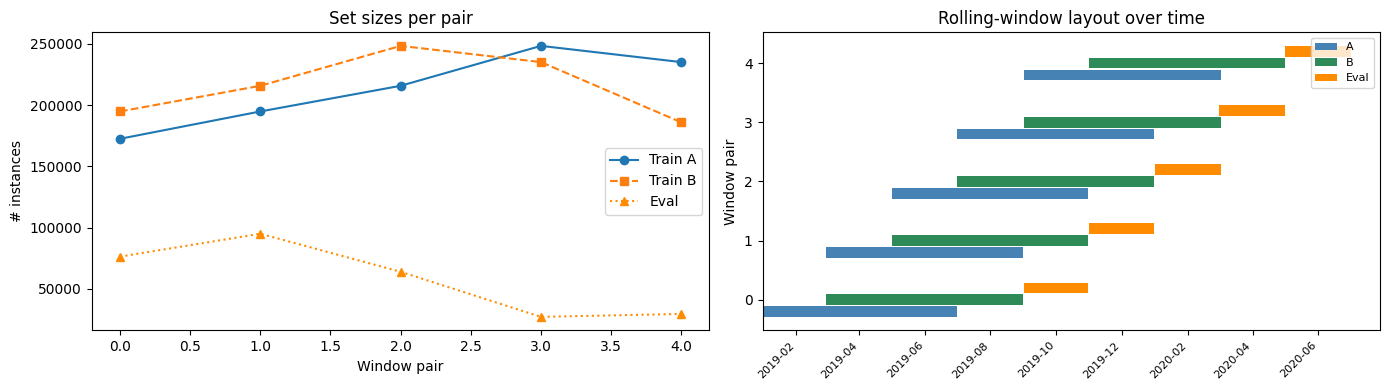

Done.


In [11]:
# Visual: training and eval set sizes per pair, plus a Gantt-style layout of
# A / B / eval over time so the rolling structure is easy to inspect.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pair_ids = [p['pair_id'] for p in pairs]
axes[0].plot(pair_ids, [p['n_train_A'] for p in pairs], 'o-', label='Train A')
axes[0].plot(pair_ids, [p['n_train_B'] for p in pairs], 's--', label='Train B')
axes[0].plot(pair_ids, [p['n_eval']    for p in pairs], '^:',  color='darkorange', label='Eval')
axes[0].set_title('Set sizes per pair')
axes[0].set_xlabel('Window pair')
axes[0].set_ylabel('# instances')
axes[0].legend()

# Gantt chart on calendar axis
import matplotlib.dates as mdates
xs = pd.to_datetime([ts for ts in time_steps])
ax = axes[1]
for p in pairs:
    pid = p['pair_id']
    a_start = xs[min(p['steps_A'])]; a_end = xs[max(p['steps_A'])]
    b_start = xs[min(p['steps_B'])]; b_end = xs[max(p['steps_B'])]
    e_start = xs[min(p['steps_eval'])]; e_end = xs[max(p['steps_eval'])]
    ax.barh(pid - 0.2, (a_end - a_start).days + 30, left=a_start, height=0.18, color='steelblue', label='A' if pid == 0 else None)
    ax.barh(pid,        (b_end - b_start).days + 30, left=b_start, height=0.18, color='seagreen',  label='B' if pid == 0 else None)
    ax.barh(pid + 0.2, (e_end - e_start).days + 30, left=e_start, height=0.18, color='darkorange', label='Eval' if pid == 0 else None)
ax.set_yticks(pair_ids)
ax.set_ylabel('Window pair')
ax.set_title('Rolling-window layout over time')
ax.legend(loc='upper right', fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(WIN_DIR / 'window_layout.png', dpi=120)
plt.show()
print('Done.')